# Analyses of model-internal activations
_[Marianne de Heer Kloots](https://mdhk.net/), Apr 2026_

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdhk/internal_tools/blob/main/tutorials/2_activation_analyses.ipynb)

This notebook walks through running two popular analysis methods for investigating what models internally encode about speech sounds, on activations extracted using `internal_tools`. **ABX tests** measure whether a model encodes two sounds of the same phone category (A and X) more similarly than two sounds of different categories (A and B) — the similarity between each pair can be measured by vector similarity metrics on the model's activation space (e.g. cosine similarities). **Probing classifiers** are simple auxiliary models which are trained to predict phone categories from model-internal activations.

For any analysis it is good practice to establish a baseline, for example by [measuring scores on randomized control tasks](https://aclanthology.org/D19-1275/), or by [comparing the performance of trained and randomly-initialized models](https://aclanthology.org/2020.acl-main.381/). We will include both in our analyses below.

The code for running the probes and ABX tests on extracted activations is implemented in the `run_phone_probe` and `run_ABX_tests` functions in [`analysis_utils.py`](https://github.com/mdhk/internal_tools/blob/main/tutorials/analysis_utils.py); check out these functions for more details on the analyses themselves.

**Note:** If on Colab, activating a GPU runtime is advisable (_Runtime_ > _Change runtime type_).

## Set up notebook environment

The cell below is needed when running this notebook on Colab. It will restart the session after running; when the session has restarted, `internal_tools` will be available for importing (you can ignore warnings about the session crashing).

In [1]:
# @title Fetch & install internal_tools
%cd /content
!if [ ! -d "internal_tools" ]; then git clone -qq https://github.com/mdhk/internal_tools.git; fi
%cd internal_tools
!uv pip install -e .
exit()

/content
/content/internal_tools
Using Python 3.12.13 environment at: /usr
Resolved 80 packages in 1.11s
Prepared 1 package in 1.95s
Installed 1 package in 0.98ms
 + internal-tools==0.1.0 (from file:///content/internal_tools)


The cell below will download the needed data and model files for this tutorial into the notebook environment.

In [1]:
# @title Download tutorial files
%cd /content/internal_tools/tutorials
!if [ ! -d "data" ]; then bash download_tutorial_files.sh data; fi
!if [ ! -d "models" ]; then bash download_tutorial_files.sh models; fi

/content/internal_tools/tutorials
Downloading...
From (original): https://drive.google.com/uc?id=1zkQ_7SfvEWRJ86dBdjmdIo5sQm87PQzO
From (redirected): https://drive.google.com/uc?id=1zkQ_7SfvEWRJ86dBdjmdIo5sQm87PQzO&confirm=t&uuid=5e3a7f1d-2f35-4920-9bd3-c3a9dbf34d76
To: /content/internal_tools/tutorials/data.zip
100% 127M/127M [00:01<00:00, 71.5MB/s]
Unzipping 'data.zip'...
Done!
Downloading...
From (original): https://drive.google.com/uc?id=129Fkg_bQpVB_yN-YT5MVK6ulZS_zjhH6
From (redirected): https://drive.google.com/uc?id=129Fkg_bQpVB_yN-YT5MVK6ulZS_zjhH6&confirm=t&uuid=ab97a160-398b-4248-873d-ca89b4bf7231
To: /content/internal_tools/tutorials/models.zip
100% 1.20G/1.20G [00:18<00:00, 65.6MB/s]
Unzipping 'models.zip'...
Done!


### Library imports

In [2]:
%cd /content/internal_tools/tutorials
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import gc
import os
import torch

from tqdm import tqdm
from pathlib import Path
from collections import defaultdict

from huggingface_hub import hf_hub_download

from transformers import (
    Wav2Vec2Model,
    Wav2Vec2ForCTC,
    Wav2Vec2Config,
    HubertModel,
    HubertForCTC,
    HubertConfig,
    WavLMModel,
    WavLMForCTC,
    WavLMConfig
)
from internal_tools.models import (
    load_CPC_model,
    CPCConfig,
    load_SpidR_model,
    SpidRConfig,
    load_MelHuBERT_model,
    load_BabyHuBERT_model
)

from internal_tools.extractors import AudioModelExtractor
from internal_tools.preprocessors import AudioPreprocessor
from internal_tools.dataset_utils import get_annotated_audio_loader

from analysis_utils import create_ABX_triplets, run_phone_probe, run_ABX_tests

%matplotlib inline

/content/internal_tools/tutorials


### Environment & global variables

In [3]:
ROOT = Path('')
DATADIR = ROOT/'data/'
MODELDIR = ROOT/'models/'
for model_cache_var in ["HF_HOME", "TORCH_HOME"]:
    os.environ[model_cache_var] = str(MODELDIR)
RESULTSDIR = ROOT/'results/'
FIGDIR = ROOT/'figures/'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


## Prepare analysis data

### Annotations and dataloader
For both analyses we'll need a prepared dataset of audio files with time-aligned phone labels. We'll use the LibriSpeech phone sample for this and prepare the data for batch processing (see the [phone sample](https://github.com/mdhk/internal_tools/main/tutorials/0_sampling_librispeech_phones.ipynb) and [activation extraction](https://github.com/mdhk/internal_tools/blob/main/tutorials/1_extracting_model_activations.ipynb) notebooks for more details).

In [4]:
phone_annotations = pd.read_csv(DATADIR/'libri_phone_sample/libri_phone_sample.csv')
dl = get_annotated_audio_loader(phone_annotations, DATADIR/'libri_phone_sample/audio', batch_size=20)

### Probing train-test splits
Since the probing classifiers are trained, we will want to evaluate them on held-out test data. We'll here split the phone sample by speaker (training on 8 speakers and testing on 2 others). We'll do this five times so we can use cross-validate the probing classifier accuracies across 5 folds.

In [5]:
Nfolds = 5
test_speakers = {
    f: [
        phone_annotations[phone_annotations['speaker_sex'] == 'F']['speaker_id'].unique()[f].item(),
        phone_annotations[phone_annotations['speaker_sex'] == 'M']['speaker_id'].unique()[f].item()
    ] for f in range(Nfolds)
}

fold_splits = {
    f: {
        'train': phone_annotations[~phone_annotations['speaker_id'].isin(test_speakers[f])].index.values,
        'test': phone_annotations[phone_annotations['speaker_id'].isin(test_speakers[f])].index.values
    } for f in range(Nfolds)
}

A predefined set of fold splits is loaded below (for reproducability).



In [6]:
fold_splits = {int(k): v for k, v in json.load(open(DATADIR/'analysis_files/phone_probe/fold_splits.json', 'r')).items()}

### ABX triplets
ABX scores are computed over _triplets_ of speech sounds A, B, and X, where A and X belong to the same category but B is different. To generate a set of triplets we'll first define which contrasting sounds we want to include in our ABX test measurements. The cell below loads a predefined set of contrasts.

In [7]:
phone_contrasts = pd.read_csv(DATADIR/'analysis_files/phone_ABX/phone_contrasts.csv')
phone_contrasts

,speech_sound_category,contrast_feature,A,B
0,consonants,voicing,θ,ð
1,consonants,voicing,p,b
2,consonants,voicing,t,d
3,consonants,voicing,f,v
4,consonants,voicing,s,z
...,...,...,...,...
56,vowels,close-open,eɪ,ai
57,vowels,close-open,ɔ,u
58,vowels,close-open,oʊ,u
59,vowels,close-open,aʊ,oʊ


ABX tests come in different [types](https://zerospeech.com/tasks/task_1/metrics/#types-of-abx-phoneme-discrimination-benchmarks). We'll here consider a _within-speaker_ condition (where A, B, and X are all sampled from the same speaker) and an _across-speaker_ condition (where A, B, and X are sampled from different speakers). The cell below will generate a dataframe of triplets based on the the contrasts and annotations loaded above; the values in the `A_idx`, `B_idx` and `X_idx` columns refer to rows in the `phone_annotations` dataframe. In the end, the accuracy for each triplet will be determined by measuring whether model activations for A and X are more similar to eachother than activations for A and B.

In [8]:
create_ABX_triplets(phone_annotations, phone_contrasts, condition='across-speaker')

,A_idx,B_idx,X_idx,A_phone,B_phone,X_phone,A_speaker_id,B_speaker_id,X_speaker_id,A_speaker_sex,B_speaker_sex,X_speaker_sex,A_file_id,B_file_id,X_file_id,speech_sound_category,contrast_feature,ABX_condition
0,340,595,3495,θ,ð,θ,3853,5895,6241,F,F,M,3853-163249-0049,5895-34615-0016,6241-61943-0027,consonants,voicing,across-speaker
1,341,598,1047,θ,ð,θ,3853,5895,1993,F,F,F,3853-163249-0016,5895-34629-0009,1993-147149-0006,consonants,voicing,across-speaker
2,342,3393,2447,θ,ð,θ,3853,6241,3752,F,M,M,3853-163249-0034,6241-66616-0019,3752-4943-0007,consonants,voicing,across-speaker
3,343,3047,1397,θ,ð,θ,3853,652,5338,F,M,F,3853-163249-0000,652-130726-0021,5338-284437-0024,consonants,voicing,across-speaker
4,344,3394,1746,θ,ð,θ,3853,6241,2412,F,M,F,3853-163249-0003,6241-66616-0016,2412-153954-0003,consonants,voicing,across-speaker
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6095,3480,964,2434,ʌ,ɑ,ʌ,6241,1993,3752,M,F,M,6241-61943-0027,1993-147149-0017,3752-4943-0001,vowels,close-open,across-speaker
6096,3481,1662,1387,ʌ,ɑ,ʌ,6241,2412,5338,M,F,F,6241-61943-0017,2412-153954-0023,5338-24615-0011,vowels,close-open,across-speaker
6097,3482,1661,2788,ʌ,ɑ,ʌ,6241,2412,6295,M,F,M,6241-61943-0027,2412-153954-0009,6295-244435-0008,vowels,close-open,across-speaker
6098,3483,2368,681,ʌ,ɑ,ʌ,6241,3752,5895,M,M,F,6241-61946-0015,3752-4944-0016,5895-34622-0019,vowels,close-open,across-speaker


The cell below loads predefined triplet sets for the _within-speaker_ and _across-speaker_ conditions, as well as a set of _random_ triplets (with randomly sampled phone occurrences) for control analyses.

In [9]:
within_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_within-speaker.csv')
across_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_across-speaker.csv')
random_ABX_triplets = pd.read_csv(DATADIR/'analysis_files/phone_ABX/ABX_triplets_random.csv')

## Model & preprocessor loading

The `model_names` list below contains a few reference names for example models to load, for demonstration purposes. See the `load_preprocessor` and `load_model` function contents for how to load the necessary components for each of these models.

Note: loading the `babyhubert` model requires you to sign an agreement at the HuggingFace hub (see the [BabyHuBERT model card](https://huggingface.co/MarvinLvn/BabyHuBERT)) and have your `HF_TOKEN` available as an environment variable (for example within your Colab notebook secrets). The BabyHuBERT model repository does not contain a preprocessor configuration, so loading a preprocessor for this model will default to a standard Wav2Vec2FeatureExtractor.

In [10]:
model_names = ['wav2vec2', 'wav2vec2-ctc', 'hubert', 'hubert-ctc', 'babyhubert', 'wavlm', 'wavlm-ctc', 'spidr', 'cpc', 'melhubert']

In [11]:
def load_preprocessor(model_name):
    match model_name:
        case 'wav2vec2':
            return AudioPreprocessor.for_hf_model('facebook/wav2vec2-base')
        case 'wav2vec2-ctc':
            return AudioPreprocessor.for_hf_model('facebook/wav2vec2-base-960h')
        case 'hubert':
            return AudioPreprocessor.for_hf_model('facebook/hubert-base-ls960')
        case 'hubert-ctc':
            return AudioPreprocessor.for_hf_model('facebook/hubert-large-ls960-ft')
        case 'babyhubert':
            return AudioPreprocessor.for_hf_model('MarvinLvn/BabyHuBERT')
        case 'wavlm':
            return AudioPreprocessor.for_hf_model('microsoft/wavlm-base')
        case 'wavlm-ctc':
            return AudioPreprocessor.for_hf_model('patrickvonplaten/wavlm-libri-clean-100h-base')
        case 'spidr':
            return AudioPreprocessor.for_spidr_model()
        case 'cpc':
            return AudioPreprocessor.for_cpc_model()
        case 'melhubert':
            return AudioPreprocessor.for_melhubert_model()

def load_model(model_name, trained=True):
    match model_name:
        case 'wav2vec2':
            if trained:
                return Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base', cache_dir=MODELDIR)
            else:
                return Wav2Vec2Model(Wav2Vec2Config())
        case 'wav2vec2-ctc':
            if trained:
                return Wav2Vec2ForCTC.from_pretrained('facebook/wav2vec2-base-960h', cache_dir=MODELDIR)
            else:
                return Wav2Vec2ForCTC(Wav2Vec2Config())
        case 'hubert':
            if trained:
                return HubertModel.from_pretrained('facebook/hubert-base-ls960', cache_dir=MODELDIR)
            else:
                return HubertModel(HubertConfig())
        case 'hubert-ctc':
            if trained:
                return HubertForCTC.from_pretrained('facebook/hubert-large-ls960-ft', cache_dir=MODELDIR)
            else:
                return HubertForCTC(HubertConfig())
        case 'babyhubert':
            if trained:
                return load_BabyHuBERT_model(hf_hub_download(repo_id="MarvinLvn/BabyHuBERT", filename="BabyHuBERT.ckpt", cache_dir=MODELDIR))
            else:
                return load_BabyHuBERT_model()
        case 'wavlm':
            if trained:
                return WavLMModel.from_pretrained('microsoft/wavlm-base', cache_dir=MODELDIR)
            else:
                return WavLMModel(WavLMConfig())
        case 'wavlm-ctc':
            if trained:
                return WavLMForCTC.from_pretrained('patrickvonplaten/wavlm-libri-clean-100h-base', cache_dir=MODELDIR)
            else:
                return WavLMForCTC(WavLMConfig())
        case 'spidr':
            if trained:
                return torch.hub.load("facebookresearch/spidr", "spidr_base")
            else:
                return load_SpidR_model(SpidRConfig())
        case 'cpc':
            if trained:
                return load_CPC_model(f"{MODELDIR}/cpc_checkpoint_106.pt")
            else:
                return load_CPC_model(CPCConfig())
        case 'melhubert':
            if trained:
                return load_MelHuBERT_model(f"{MODELDIR}/melhubert_960_stage2_20ms.ckpt")
            else:
                return load_MelHuBERT_model(config='default_20ms')

## Activation extraction & analyses
The cell below will extract mean-pooled activations for all phone segments in the LibriSpeech phone sample, and then run the probe and ABX analyses.

Change the `model_name` and `trained` variables on top to explore results for different models.

In [12]:
model_name = 'babyhubert'
trained = True
save_result_files = False

model = load_model(model_name, trained=trained)
model.eval()
model.to(device)

preprocessor = load_preprocessor(model_name)

# initialize the extractor (with default configurations)
extr = AudioModelExtractor(model)

# we will store batchwise activations & indices here
actv_indices = []
activations = defaultdict(list)

print('Extracting activations...')
for b, batch_data in tqdm(enumerate(dl), desc=f'For {len(dl)} batches', total=len(dl)):

    # prepare audio inputs
    inputs = preprocessor(
        batch_data['audio_signal'],
        sampling_rate=batch_data['audio_sampling_rate'],
        padding=True,
        return_tensors="pt",
        padding_side="right"
    ).to(device)

    # max length of all the waveforms in this batch
    max_audio_size = max([len(s) for s in batch_data['audio_signal']])

    # run forward pass
    with torch.no_grad():
        if model_name == 'melhubert':
            outputs = model(inputs.input_values, inputs.attention_mask)
        else:
            outputs = model(inputs.input_values)

    # extract and mean-pool segment activations
    extracted_actv_indices, extracted_acts = extr.get_indexed_segment_activations(
        segment_index=batch_data['annotation_indices'],
        segment_start_times=batch_data['annotation_start_times'],
        segment_end_times=batch_data['annotation_end_times'],
        input_size=max_audio_size,
        pooling='mean'
    )

    # clear memory
    extr.clear()
    del inputs, outputs
    gc.collect()
    torch.cuda.empty_cache()

    # store extracted activations & their indices
    actv_indices.extend(extracted_actv_indices)
    for layer in extracted_acts:
        activations[layer].extend(extracted_acts[layer])

# reorder extracted activations by indices & stack
for layer in activations.keys():
    activations[layer] = np.stack([activations[layer][i] for i in np.argsort(actv_indices)])
print('Done!')
print(f'Extracted activations for {model_name} layers:', list(activations.keys()))

first_model_layer = 'embeds' if not model_name == 'cpc' else 'LSTM'

# here we run analyses on the extracted activations
print('Running probing classifiers...')
print('True labels')
probe_true_results = run_phone_probe(
    activations, phone_annotations, fold_splits,
    first_model_layer=first_model_layer
)
print('Randomized labels')
probe_control_results = run_phone_probe(
    activations, phone_annotations, fold_splits,
    first_model_layer=first_model_layer,
    randomize_labels=True
)

print('Running ABX tests...')
print('within-speaker')
ABX_within_results = run_ABX_tests(
    activations,
    within_ABX_triplets,
    device=device,
    first_model_layer=first_model_layer
)
print('across-speaker')
ABX_across_results = run_ABX_tests(
    activations,
    across_ABX_triplets,
    device=device,
    first_model_layer=first_model_layer
)
print('random')
ABX_random_results = run_ABX_tests(
    activations,
    random_ABX_triplets,
    device=device,
    first_model_layer=first_model_layer
)
print('Done!')

if save_result_files:
    model_init = 'trained' if trained else 'untrained'
    probe_true_results.to_csv(RESULTSDIR / f"probe-results_true-labels_{model_name}_{model_init}.csv", index=False)
    probe_control_results.to_csv(RESULTSDIR / f"probe-results_randomized-labels_{model_name}_{model_init}.csv", index=False)
    ABX_within_results.to_csv(RESULTSDIR / f"ABX-results_within-speaker_{model_name}-{model_init}.csv", index=False)
    ABX_across_results.to_csv(RESULTSDIR / f"ABX-results_across-speaker_{model_name}-{model_init}.csv", index=False)
    ABX_random_results.to_csv(RESULTSDIR / f"ABX-results_random_{model_name}-{model_init}.csv", index=False)

# clear memory
del model, extr, activations
gc.collect()
torch.cuda.empty_cache()

BabyHuBERT.ckpt:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

/content/internal_tools/internal_tools/preprocessors.py:30: UserWarning: No preprocessor_config.json file found for MarvinLvn/BabyHuBERT, using default Wav2Vec2FeatureExtractor instead. Settings: 
{'feature_size': 1, 'sampling_rate': 16000, 'padding_value': 0.0, 'padding_side': 'right', 'return_attention_mask': False, 'do_normalize': True, 'feature_extractor_type': 'Wav2Vec2FeatureExtractor'}
  warnings.warn(


Extracting activations...


...

across-speaker


100%|██████████| 14/14 [01:08<00:00,  4.90s/it]


random


100%|██████████| 14/14 [01:09<00:00,  4.94s/it]


Done!


## Plot results
Pre-computed results for all example models are downloaded by running the cell below.

In [13]:
!if [ ! -d "results" ]; then bash download_tutorial_files.sh results; fi

Downloading...
From (original): https://drive.google.com/uc?id=1IG99ZTXOVG78xaobXMo7DsKpokQG06-0
From (redirected): https://drive.google.com/uc?id=1IG99ZTXOVG78xaobXMo7DsKpokQG06-0&confirm=t&uuid=807ddb0f-4572-4f79-a93b-5599e80397f4
To: /content/internal_tools/tutorials/results.zip
100% 212M/212M [00:03<00:00, 62.1MB/s]
Unzipping 'results.zip'...
Done!


Let's plot the layerwise results for all models to compare results!

### Probe results

In [14]:
model_names = ['wav2vec2', 'wavlm', 'spidr', 'hubert', 'babyhubert', 'melhubert', 'cpc']
trained_model_probe_results = {
    model_name: {
        label_setting: pd.read_csv(RESULTSDIR/f'probe-results_{label_setting}-labels_{model_name}-trained.csv')
        for label_setting in ['true', 'randomized']
    }
    for model_name in model_names
}
untrained_model_probe_results = {
    model_name: {
        label_setting: pd.read_csv(RESULTSDIR/f'probe-results_{label_setting}-labels_{model_name}-untrained.csv')
        for label_setting in ['true', 'randomized']
    }
    for model_name in model_names
}

In [15]:
# @title Plotting function
def plot_probe_results(probe_results, title='', filepath=None, model_names=model_names):
    sns.set_style('whitegrid')
    mpl.rcParams['axes.linewidth'] = 2
    mpl.rcParams['axes.edgecolor'] = '0.9'
    width_frac = 1
    if 'cpc' in model_names:
        cpc_idx = model_names.index('cpc')
        cpc_frac = width_frac/4
    width_ratios = [width_frac if not mn == 'cpc' else cpc_frac for mn in model_names]

    fig, axs = plt.subplots(1, len(model_names), figsize=(2.25*len(model_names),3), width_ratios=width_ratios, sharey=True)

    for mn, model_name in enumerate(model_names):
        ax = axs[mn]
        results = probe_results[model_name]
        foldavg_true = results['true'].groupby(['fold', 'layer', 'depth'], as_index=False).agg({'score': 'mean'})
        foldavg_control = results['randomized'].groupby(['fold', 'layer', 'depth'], as_index=False).agg({'score': 'mean'})
        sns.lineplot(foldavg_true, x='depth', y='score', ax=ax, label='true phone labels')
        sns.lineplot(foldavg_control, x='depth', y='score', dashes=(1,2), color='grey', ax=ax, label='randomized labels')
        layer_depths = dict(zip(results['true']['layer'].unique(), results['true']['depth'].unique()))
        ax.set_xticks(list(layer_depths.values()), list(layer_depths.keys()), rotation=90)
        ax.set_xlim(list(layer_depths.values())[0], list(layer_depths.values())[-1])
        ax.set_xlabel('')
        ax.set_ylabel('accuracy')
        ax.set_ylim(0,1)
        if mn == 0:
            ax.legend(frameon=False, ncol=2, bbox_to_anchor=(7.4,1.33,0,0))
        else:
            ax.legend().remove()
        ax.set_title(model_name, ha='left', x=0)
    if title:
        plt.suptitle(title.upper(), ha='left', x=0.095, y=1.1, fontweight='bold')
    if filepath:
        if not filepath.parent.exists():
            Path(filepath.parent).mkdir(exist_ok=True, parents=True)
        plt.savefig(filepath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

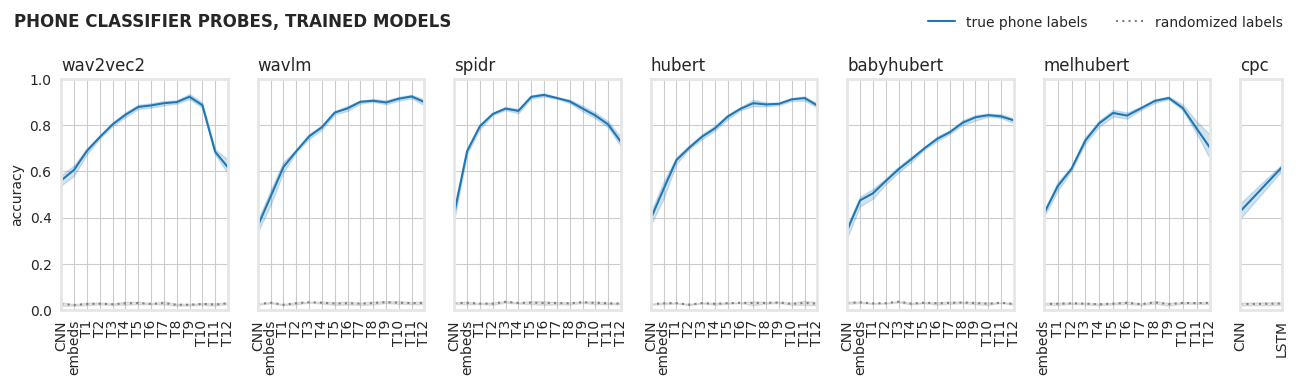

In [16]:
plot_probe_results(
    trained_model_probe_results,
    title='phone classifier probes, trained models',
    filepath=FIGDIR/'trained-model_probe-results.png'
)

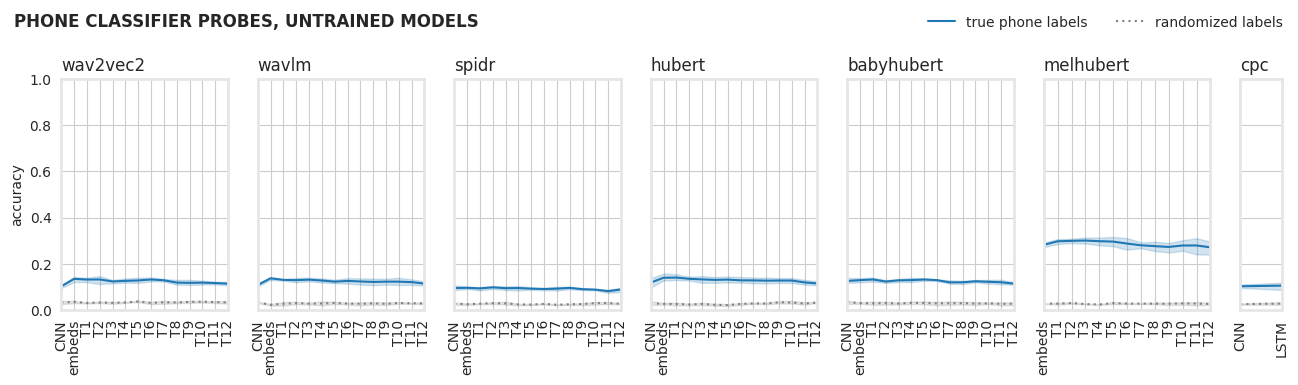

In [17]:
plot_probe_results(
    untrained_model_probe_results,
    title='phone classifier probes, untrained models',
    filepath=FIGDIR/'untrained-model_probe-results.png'
)

## Plot ABX results

In [18]:
model_names = ['wav2vec2', 'wavlm', 'spidr', 'hubert', 'babyhubert', 'melhubert', 'cpc']
trained_model_ABX_results = {
    model_name: {
        condition: pd.read_csv(RESULTSDIR/f'ABX-results_{condition}_{model_name}-trained.csv')
        for condition in ['within-speaker', 'across-speaker', 'random']
    }
    for model_name in model_names
}
untrained_model_ABX_results = {
    model_name: {
        condition: pd.read_csv(RESULTSDIR/f'ABX-results_{condition}_{model_name}-untrained.csv')
        for condition in ['within-speaker', 'across-speaker', 'random']
    }
    for model_name in model_names
}

In [19]:
# @title Plotting function
def plot_ABX_results(ABX_results, title='', filepath=None, model_names=model_names, conditions=['within-speaker', 'across-speaker', 'random']):
    sns.set_style('whitegrid')
    mpl.rcParams['axes.linewidth'] = 2
    mpl.rcParams['axes.edgecolor'] = '0.9'
    width_frac = 1
    if 'cpc' in model_names:
        cpc_idx = model_names.index('cpc')
        cpc_frac = width_frac/4
    width_ratios = [width_frac if not mn == 'cpc' else cpc_frac for mn in model_names]

    fig, axs = plt.subplots(1, len(model_names), figsize=(2.25*len(model_names),3), width_ratios=width_ratios, sharey=True)

    for mn, model_name in enumerate(model_names):
        ax = axs[mn]
        results = ABX_results[model_name]
        for condition in conditions:
            condition_results = results[condition]
            if condition == 'within-speaker':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='within-speaker', color=sns.color_palette("Paired")[3])
            elif condition == 'across-speaker':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='across-speaker', color=sns.color_palette("Paired")[2])
            elif condition == 'random':
                sns.lineplot(condition_results, x='depth', y='accuracy', ax=ax, label='random', color='grey', dashes=(1,2))
        layer_depths = dict(zip(results[conditions[0]]['layer'].unique(), results[conditions[0]]['depth'].unique()))
        ax.set_xticks(list(layer_depths.values()), list(layer_depths.keys()), rotation=90)
        ax.set_xlim(list(layer_depths.values())[0], list(layer_depths.values())[-1])
        ax.set_xlabel('')
        ax.set_ylabel('accuracy')
        ax.set_ylim(0.45,1)
        if mn == 0:
            ax.legend(frameon=False, ncol=3, bbox_to_anchor=(7.4,1.33,0,0))
        else:
            ax.legend().remove()
        ax.set_title(model_name, ha='left', x=0)
    if title:
        plt.suptitle(title.upper(), ha='left', x=0.095, y=1.1, fontweight='bold')
    if filepath:
        if not filepath.parent.exists():
            Path(filepath.parent).mkdir(exist_ok=True, parents=True)
        plt.savefig(filepath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

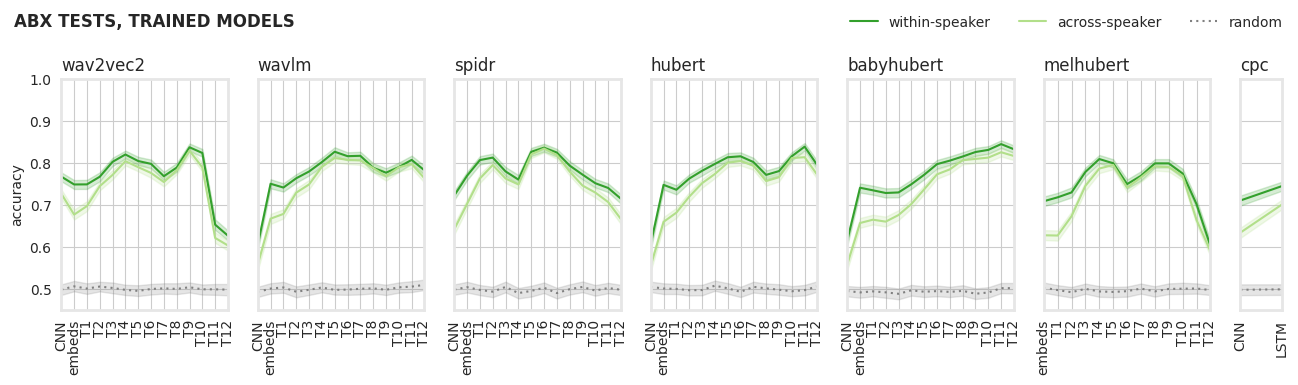

In [20]:
plot_ABX_results(
    trained_model_ABX_results,
    title='ABX tests, trained models',
    filepath=FIGDIR/'trained-model_ABX-results.png'
)

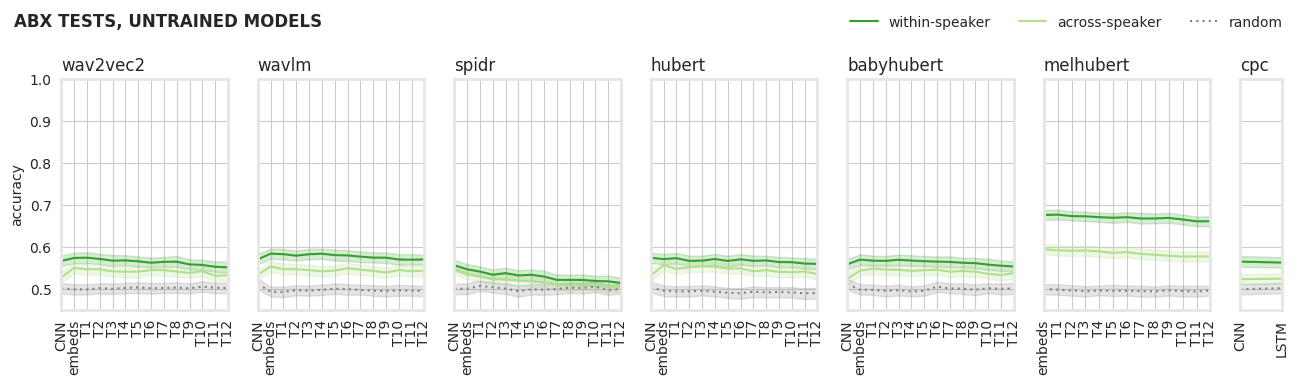

In [21]:
plot_ABX_results(
    untrained_model_ABX_results,
    title='ABX tests, untrained models',
    filepath=FIGDIR/'untrained-model_ABX-results.png'
)